# Linear Regression

In [1]:
# importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Importing the data

In [2]:
data = pd.read_csv('train_cleaned.csv')
data.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_LF,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,3735.1380,0,1,0,0,0,...,0,1,0,1,0,0,0,1,0,0
1,5.92,0.019278,48.2692,2009,443.4228,0,0,1,0,0,...,0,1,0,0,0,1,0,0,1,0
2,17.50,0.016760,141.6180,1999,2097.2700,0,1,0,0,0,...,0,1,0,1,0,0,0,1,0,0
3,19.20,0.000000,182.0950,1998,732.3800,0,0,1,0,0,...,0,0,0,0,0,1,1,0,0,0
4,8.93,0.000000,53.8614,1987,994.7052,0,1,0,0,0,...,1,0,0,0,0,1,0,1,0,0


## Segregating dependent and independent variables

In [3]:
data.shape

(8523, 46)

In [4]:
x = data.drop('Item_Outlet_Sales',axis=1) # independent variables x
y = data['Item_Outlet_Sales']             # dependent variable y
x.shape,y.shape

((8523, 45), (8523,))

## Splitting train and test data

In [5]:
# Splitting the test and train data
from sklearn.model_selection import train_test_split as tts
train_x,test_x,train_y,test_y = tts(x,y,random_state=27)
train_x.shape,test_x.shape

((6392, 45), (2131, 45))

## Implementing Linear Regression

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error as mae

### Creating an instance of linear regression

In [7]:
lin_reg = LinearRegression()

# Fitting the model (FOR TRAIN DATA)
lin_reg.fit(train_x,train_y)

LinearRegression()

### Parameters of linear regression

In [8]:
lin_reg.coef_

array([ 6.29616598e-01, -2.38670506e+02,  1.56685923e+01, -1.99485747e+01,
       -3.77906802e+01, -4.49688595e+00,  2.79844521e+01,  1.34349543e+02,
       -1.20046429e+02, -1.95667834e+01,  2.00227418e+01, -4.46485168e+01,
        2.01115081e+00, -4.95894586e+01, -1.75540201e+01,  7.10728218e+01,
        1.89120801e+01,  1.63655852e+01, -4.15468028e+01,  3.71435842e+01,
       -2.18968931e+01,  8.74754820e+01, -1.02304992e+01, -4.52110811e+01,
       -2.75939072e+00, -4.86958747e+02, -4.74664692e+01,  1.54353017e+02,
       -3.66625702e+01, -4.60367827e+02,  5.86439603e+02,  1.39090465e+02,
       -8.89645345e+01,  3.04128625e+02, -6.35915611e+01, -4.74664692e+01,
        4.86185471e+02, -1.71487375e+01, -2.19830764e+02,  2.04478947e+02,
        1.53518166e+01, -9.47326574e+02,  3.97549542e+02, -3.66625702e+01,
        5.86439603e+02])

In [9]:
lin_reg.intercept_

39422.515182061165

### Predicting over train and test dataset

In [10]:
# predicting on the train data
train_pred = lin_reg.predict(train_x)
train_mae = round(mae(train_y,train_pred),2)

# predicting on the test data
test_pred = lin_reg.predict(test_x)
test_mae = round(mae(test_y,test_pred),2)

train_mae , test_mae

(827.12, 859.66)

### Plotting the coefficients

Text(0.5, 1.0, 'Linear Regression Coeffecients')

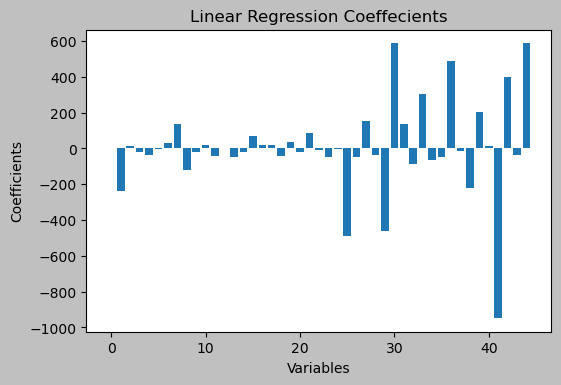

In [11]:
plt.figure(figsize=(6,4),dpi=100,facecolor='silver')
x_plot = range(len(lin_reg.coef_))
y_plot = lin_reg.coef_
plt.bar(x_plot,y_plot)
plt.xlabel('Variables')
plt.ylabel('Coefficients')
plt.title("Linear Regression Coeffecients")

### Checking assumptions of linear model

In [12]:
# Calculating the residuals
residual_table = pd.DataFrame({"Fitted_y":test_y,"Predicted_y":test_pred})
residual_table['Residual'] = residual_table['Fitted_y'] - residual_table['Predicted_y'] 
residual_table.head()

,Fitted_y,Predicted_y,Residual
7377,1254.3672,3443.686920,-2189.319720
3078,2233.0932,2717.638425,-484.545225
6505,1917.5040,4454.263102,-2536.759102
4686,1619.2256,1574.941573,44.284027
3093,5681.2714,3823.707297,1857.564103


Text(0.5, 1.0, 'Residual Plot')

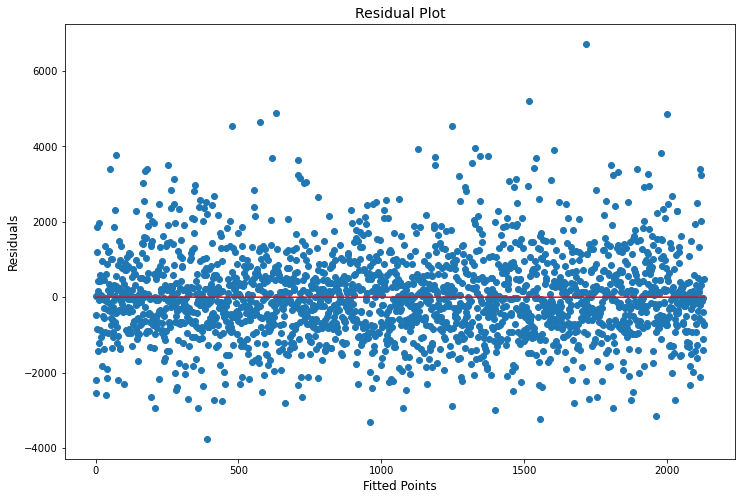

In [13]:
plt.figure(figsize=(12,8))
zero_line = [0 for i in range(len(residual_table))]
plt.scatter(range(len(residual_table['Residual'])),residual_table['Residual'])
plt.plot(list(range(0, 2131)),zero_line,color = 'red')
plt.xlabel("Fitted Points", fontsize = 12)
plt.ylabel("Residuals", fontsize = 12)
plt.title("Residual Plot", fontsize = 14)

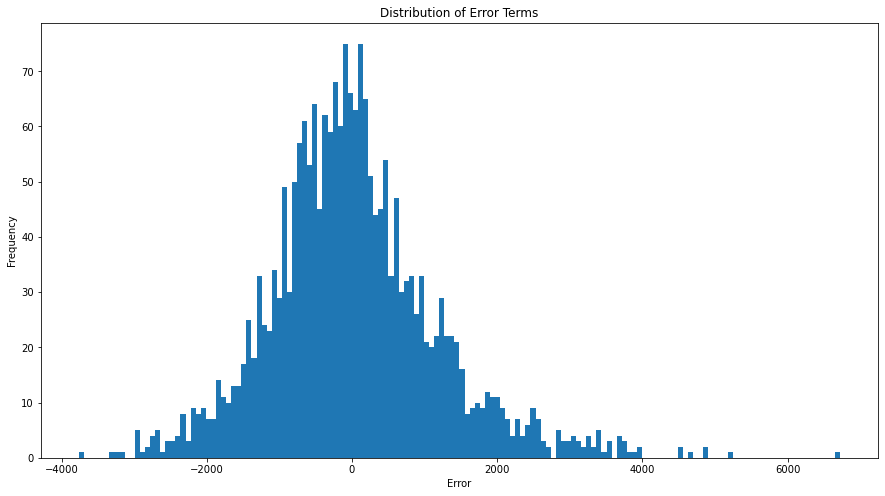

In [14]:
# Checking distribution of residuals using Histogram
plt.figure(figsize=(15,8))
plt.hist(residual_table['Residual'], bins=150)
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Distribution of Error Terms')
plt.show()

### Q-Q plot to check whether data is normally distributed


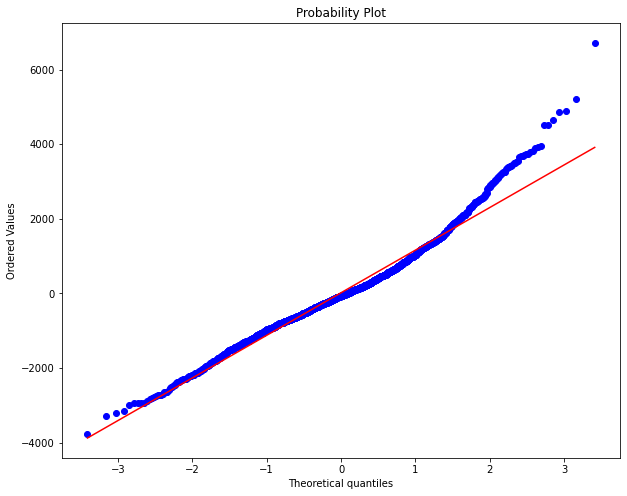

In [15]:
import pylab 
import scipy.stats as stats

plt.figure(figsize=(10,8)) 
stats.probplot(residual_table['Residual'], dist="norm", plot=pylab)
pylab.show()

### Checking the multi colinearity using Variance Inflation Factor

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

### NOT UNDERSTOOD ###